In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


## Loading the dataset

Two datasets are provided for this project:

- **train.csv** - Contains the training data along with the Target variable.
- **test.csv** - Contains unseen observations for which the predictions is generated.

In [2]:
train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")

/tmp/ipykernel_16/2549451149.py:1: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


## Preview of the Training dataset

The first five rows of the training dataset helps us to understand the overall dataset structure, avaliable features, types of values in each columns, the target variable from which the model will learn to predict.

In [3]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


## Dimension of the Training and Testing datasets

The shape of the dataset provides information on the following:

- The number of observations (rows)
- The number of features (columns)

In [4]:
print("Training dataset dimension: ", train.shape)
print("Testing dataset dimension: ", test.shape)

Training dataset dimension:  (138701, 50)
Testing dataset dimension:  (15000, 49)


## Feature list

Displaying the column names which would help in analyzing, preprocessing and training the model.

In [5]:
train.columns

Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'DataOriginCode', 'VendorPartnerID', 'ManufactureYear',
       'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate',
       'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass',
       'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor',
       'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory',
       'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3',
       'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9',
       'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18',
       'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27',
       'col28', 'col29', 'col30'],
      dtype='object')

## Dataset Information

The "info()" function helps us to get the concise summary of the dataset, including:

- Feature names
- The number of observations
- The data-type of each feature
- The count of non-null values in each column
- Memory usage

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

## Desciptive Statistics of Numerical Features

The "describe()" function provides useful information for each numerical feature, including:

- Count
- Mean
- Standard Deviation
- Maximum
- Minimum
- Quartiles(25%, 50%, 75%)

In [7]:
train.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


## Missing Value Analysis

Analyzing missing values helps determine which feature requires imputation and whether any feature have excessive missing values.

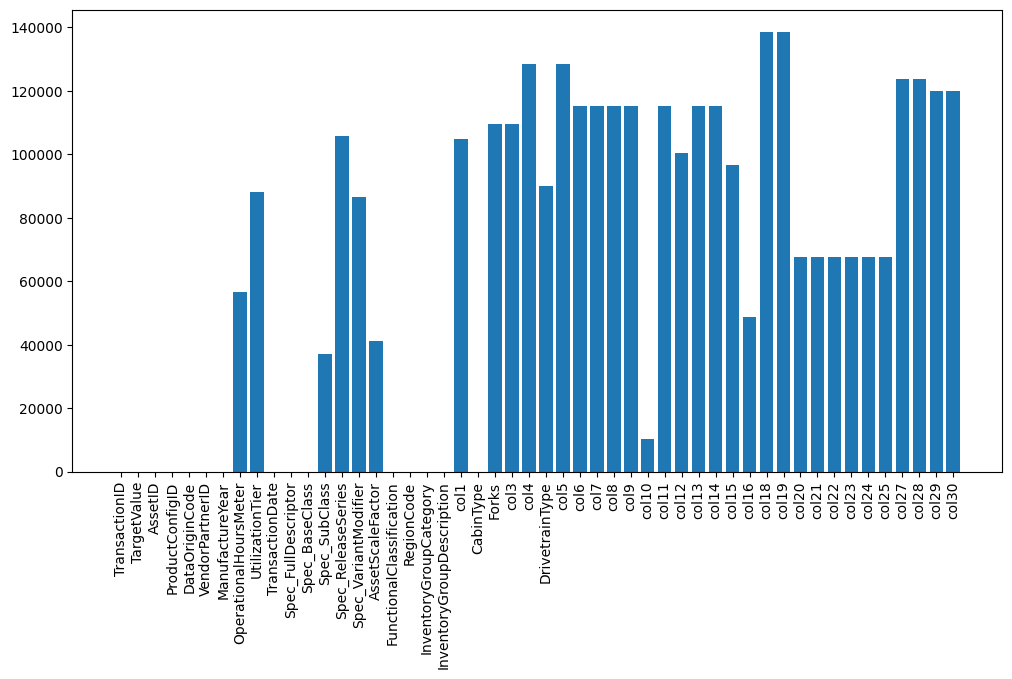

In [8]:
import matplotlib.pyplot as plt
missing = train.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.xticks(rotation=90)
plt.bar(missing.index, missing.values)
plt.show()

## Distribution of the Target Value

The Target Variable represents the selling price of each equipment. Understanding its distribution provides insights into:

- The range of selling prices
- Whether the dataset is normally distributed or skewed

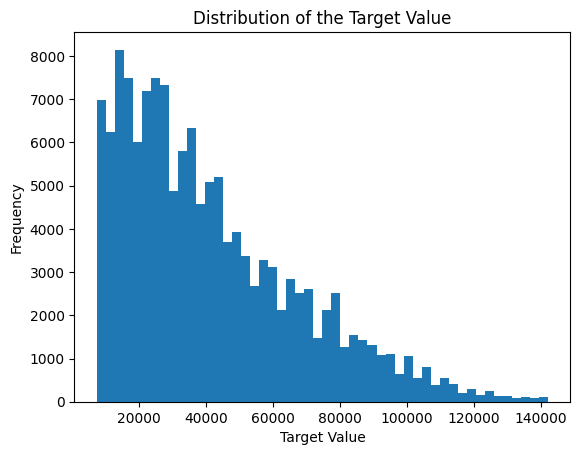

In [9]:
import matplotlib.pyplot as plt

plt.hist(train['TargetValue'], bins=50)
plt.title("Distribution of the Target Value")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

In [10]:
train['TargetValue'].describe()

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

## Unique values in each feature

The "nunique()" function helps us understand the uniqueness or the number of unique values present in each feature. This would further help in applying the appropriate preprocessing techniques such as OneHotEncoding.

In [11]:
train.nunique() 

TransactionID                138701
TargetValue                     675
AssetID                      120111
ProductConfigID                3594
DataOriginCode                    6
VendorPartnerID                  31
ManufactureYear                  68
OperationalHoursMeter         14643
UtilizationTier                   3
TransactionDate                3676
Spec_FullDescriptor            3505
Spec_BaseClass                 1249
Spec_SubClass                   147
Spec_ReleaseSeries              113
Spec_VariantModifier            132
AssetScaleFactor                  6
FunctionalClassification         65
RegionCode                       53
InventoryGroupCategory            6
InventoryGroupDescription         6
col1                              4
CabinType                         3
Forks                             2
col3                              3
col4                              2
DrivetrainType                    8
col5                              2
col6                        

## Removing Features with Excessive Missing Values

Features containing high proportion of missing values doesn't have much useful information and often leads to unecessary noise while training the model. 

To simplify the dataset, the percentage of columns which have more than **80%**  missing data are being eliminated from both training and testing datasets.

In [12]:
missing_values = train.isna().mean()*100
cols_to_drop = missing_values[missing_values > 80].index

train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)

## Removing Identifier Columns

Certain features in the dataset serve as unique identifiers which doesn't provide predicitve information for estimating the eqiupment prices and also increases the model complexity. 

Features such as **AssetID** and **TransactionID** are such unique indentifiers which identifies each record uniquely rather than describing characteristic information.

In [13]:
train.drop(columns=['AssetID', 'TransactionID'], axis=1, inplace=True)
test.drop(columns=['AssetID'], axis=1, inplace=True)

## Feature Engineering: TransactionDate

Dates are in the format from which the machine learning algorithms cannot extract the useful information. 

To capture such information, the **TransactionDate** feature is futher decomposed into other components, including:

- **TransactionYear**
- **TransactionMonth**
- **TransactionDay**
- **TransactionQuarter**
- **DayofWeek** 
- **DayofYear**

In [14]:
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])

train['TransactionYear'] = train['TransactionDate'].dt.year
train['TransactionMonth'] = train['TransactionDate'].dt.month
train['TransactionDay'] = train['TransactionDate'].dt.day
train['TransactionQuarter'] = train['TransactionDate'].dt.quarter
train['DayofWeek'] = train['TransactionDate'].dt.dayofweek
train['DayofYear'] = train['TransactionDate'].dt.dayofyear

train.drop('TransactionDate', axis=1, inplace=True)

In [15]:
test['TransactionDate'] = pd.to_datetime(test['TransactionDate'])

test['TransactionYear'] = test['TransactionDate'].dt.year
test['TransactionMonth'] = test['TransactionDate'].dt.month
test['TransactionDay'] = test['TransactionDate'].dt.day
test['TransactionQuarter'] = test['TransactionDate'].dt.quarter
test['DayofWeek'] = test['TransactionDate'].dt.dayofweek
test['DayofYear'] = test['TransactionDate'].dt.dayofyear

test.drop('TransactionDate', axis=1, inplace=True)

## Feature Engineering: EquipmentAge

The manufacturing year alone does not directly indicate the condition or expect market value of a machine. Instead,the age of the equipment provides more useful information about its depreciation over time.

To capture this information, the new feature named **EquipmentAge** is engineered by substracting **TransactionYear** from **ManufactureYear**. This engineered feature also tells us about how equipment age influence the selling price of an equipment. The older machines tends to depreciate more than the newer machine. 

In [16]:
train['EquipmentAge'] = (train['TransactionYear'] - train['ManufactureYear'])
test['EquipmentAge'] = (test['TransactionYear'] - test['ManufactureYear'])

## Feature Engineering: Equipment UsagePerYear

**OperationalHoursMeter** measures how much an equipment has been used. Different machines have different usage and may have similar ages.

To normalize this difference, the new feature named **UsagePerYear** is engineered by dividing **OperationalHoursMeter** by **EquipmentAge**.

This feature provides information to better estimate the annual average intensity and helps distinguish between the heavily and lightly used machines of similar ages.

In [17]:
train['UsagePerYear'] = np.log1p(train['OperationalHoursMeter']) / (train['EquipmentAge'] + 1)
test['UsagePerYear'] = np.log1p(test['OperationalHoursMeter']) / (test['EquipmentAge'] + 1)

## Feature Engineering: Cabin Availability

A binary feature is created to indicate that if each feature has cabin related information for each piece of equipment.

Representing this type of information further simplifies the learning process for tree-based models. 

In [18]:
train['HasCabin'] = train['CabinType'].notna().astype(int)
test['HasCabin'] = test['CabinType'].notna().astype(int)

## Feature Engineering: Fork Attachment Indicator

Fork attachments represents an additional equipment characteristic that may contribute to the resale of an equipment. 

A binary feature named **HasForks** is engineered to indicate the presence or absence of fork attachments.

In [19]:
train['HasForks'] = train['Forks'].notna().astype(int)
test['HasForks'] = test['Forks'].notna().astype(int)

## Feature Engineering: Base Class Frequency

Some equipment categories appear much more than others in the dataset. To capture this information, a frequency-based feature named **BaseClassFrequency** is engineered to by counting the number of occurences of each equipment base class.

In [20]:
frequency = train['Spec_BaseClass'].value_counts()

train['BaseClassFrequency'] = train['Spec_BaseClass'].map(frequency).fillna(0)

test['BaseClassFrequency'] = test['Spec_BaseClass'].map(frequency).fillna(0)

## Feature Engineering: Vendor Frequency

Different vendors contribute varying number of equipment records in the dataset. A new feature named  **VendorFrequency** is engineered by counting the number of occurences of each vendor in the training dataset.

In [21]:
frequency = train['VendorPartnerID'].value_counts()

train['VendorFrequency'] = train['VendorPartnerID'].map(frequency).fillna(0)

test['VendorFrequency'] = train['VendorPartnerID'].map(frequency).fillna(0)

## Feature Engineering: End-of-Year Transactions

Equipment demand may vary due to factors like budgeting cycles, seasonal purchasing behaviour and several other factors. 

The new binary feature **IsEndofYear** is engineered  to indicate the transaction that took place during the final quarter of the calender year.

In [22]:
train['IsEndofYear'] = (train['TransactionMonth'] >= 10).astype(int)
test['IsEndofYear'] = (test['TransactionMonth'] >= 10).astype(int)

## Feature Engineering: Start-of-Month Transactions

Transaction behaviour may also vary within a month due to purchasing schedules and monthly planning.

The new feature **IsStartofMonth** is engineered to indicate whether a transaction occured in the first week of the month.

In [23]:
train['IsStartofMonth'] = (train['TransactionDay'] <= 7).astype(int)
train['IsEndofMonth'] = (train['TransactionDay'] >= 25).astype(int)

test['IsStartofMonth'] = (test['TransactionDay'] <= 7).astype(int)
test['IsEndofMonth'] = (test['TransactionDay'] >= 25).astype(int)

## Feature Transformation: Operational Hours

The feature **OperationalHoursMeter** exhibits a wide numerical range and is positively skewed.

A logarithmic transformation ("log1p") is applied to compress the larger numerical values while preserving the relative ordering of observations. This transformation reduces skewness and improves numerical stability during model training.

In [24]:
train['OperationalHoursMeter'] = np.log1p(train['OperationalHoursMeter'])
test['OperationalHoursMeter'] = np.log1p(test['OperationalHoursMeter'])

## Feature Engineering: Equipment Scale and Inventory Category

Capturing related categorical features into one feature may capture meaningful characteristics that may influence the selling price. 

The new feature **Scale_Inventory** is engineered by combining **AssetScaleFactor** and **InventoryGroupCategory**  into a single feature.

In [25]:
train['Scale_Inventory'] = train['AssetScaleFactor'].astype(str) + "_" + train['InventoryGroupCategory'].astype(str)
test['Scale_Inventory'] = test['AssetScaleFactor'].astype(str) + "_" + test['InventoryGroupCategory'].astype(str)

## Feature Engineering: Equipment Scale and Cabin Type

Another feature interaction is created using **AssetScaleFactor** and **CabinType** . 

This feature allows the model to consider equipment size and cabin configuration, potentially capturing meaningful information rather than depending on each feature independently.

In [26]:
train['Scale_Cabin'] = train['AssetScaleFactor'].astype(str) + "_" + train['CabinType'].astype(str)
test['Scale_Cabin'] = test['AssetScaleFactor'].astype(str) + "_" + test['CabinType'].astype(str)

## Preparing High Cardinality Categorical Features

Some categorical features are stored as numerical values even though they represent categories rather than numerical quantities.

One such feature is **ProductConfigID** . Each value represents a unique configuration for each record rather than numerical measurement. Therefore, each value is converted to a string so that it can be treated as a categorical column instead of a numerical column.

In [27]:
train['ProductConfigID'] = train['ProductConfigID'].astype(str)
test['ProductConfigID'] = test['ProductConfigID'].astype(str)

## Feature Engineering: Equipment Specification Heirarchy 

The equipment specification is distributed across multiple columns such as base class and sub class.

The new feature **SpecHierarchy** is engineered by combining **Spec_BaseClass** and **Spec_SubClass**.

The feature made by combining two related categorical features helps the model to understand the underlying pattern or characteristics which further helps in the model training.

In [28]:
train['SpecHierarchy'] = (train['Spec_BaseClass'].fillna("NA") + "_" + train['Spec_SubClass'].fillna("NA"))
test['SpecHierarchy'] = (test['Spec_BaseClass'].fillna("NA") + "_" + test['Spec_SubClass'].fillna("NA"))

## Defining Ordinal Encoding for Asset Scale

The **AssetScaleFactor** contains categories with a natural ordering based on equipment size.

To preserve this order, a mapping dictionary is made that assignes increasing numerical values to progresively larger equipment categories.

This mapping would help in ordinal encoding maintaining the relative relationship between different equipment sizes.

In [29]:
scale_map = {
    "Compact": 0,
    "Mini": 1,
    "Small": 2,
    "Medium": 3,
    "Large/ Medium": 4,
    "Large": 5
}

train['AssetScaleFactor'] = train['AssetScaleFactor'].map(scale_map)
test['AssetScaleFactor'] = test['AssetScaleFactor'].map(scale_map)

## Verifying Missing Values before Preprocessing

Before constructing preprocessing pipeline, a final verification of missing values is performed.

In [30]:
train.isna().sum()

TargetValue                       0
ProductConfigID                   0
DataOriginCode                    0
VendorPartnerID                   0
ManufactureYear                   0
OperationalHoursMeter         56643
UtilizationTier               88226
Spec_FullDescriptor               0
Spec_BaseClass                    0
Spec_SubClass                 36985
Spec_ReleaseSeries           105805
Spec_VariantModifier          86369
AssetScaleFactor              80432
FunctionalClassification          0
RegionCode                        0
InventoryGroupCategory            0
InventoryGroupDescription         0
col1                         104915
CabinType                         0
Forks                        109382
col3                         109448
DrivetrainType                89956
col10                         10381
col12                        100337
col15                         96424
col16                         48745
col20                         67685
col21                       

## Analyzing the Cardinality of Categorical Features

Different categorical features have different number of unqiue categories. This would help in distinguishing between high-cardinality and low-cardinality features which would be useful in applying the appropriate preprocessing techniques.

In [31]:
categorical_cols = train.select_dtypes(include='object').columns

for col in categorical_cols:
    print(col, ":", train[col].nunique())

ProductConfigID : 3594
DataOriginCode : 6
VendorPartnerID : 31
UtilizationTier : 3
Spec_FullDescriptor : 3505
Spec_BaseClass : 1249
Spec_SubClass : 147
Spec_ReleaseSeries : 113
Spec_VariantModifier : 132
FunctionalClassification : 65
RegionCode : 53
InventoryGroupCategory : 6
InventoryGroupDescription : 6
col1 : 4
CabinType : 3
Forks : 2
col3 : 3
DrivetrainType : 8
col10 : 11
col12 : 4
col15 : 15
col16 : 3
col20 : 2
col21 : 18
col22 : 27
col23 : 3
col24 : 3
col25 : 3
Scale_Inventory : 14
Scale_Cabin : 18
SpecHierarchy : 2257


## Splitting the Dataset

To evaluate the performance of the machine learning models, the dataset is splitted into training and validation sets.

The input feature (**X**) is seperated from the target variable (**TargetValue**). Since the competition is based on Root Mean Squared Logarithmic Error (RMSLE), the logarithmic transformation is applied on the target variable before training.

In [32]:
from sklearn.model_selection import train_test_split

X = train.drop('TargetValue', axis=1)
y = np.log1p(train['TargetValue'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Seperating Numerical and Categorical Features

The dataset is divided into numerical and categorical features. The seperation allows applying appropriate preprocessing techniques such as scaling, encoding and imputation.

In [33]:
numerical_features = X_train.select_dtypes(include=['int64', 'float64','int32']).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns
numerical_features.append('AssetScaleFactor')

## Grouping Categorical Features by Cardinality

Categorical variables containing different number of unique categories requires different preprocessing techniques.

To optimize the preprocessing, the categories are further divided into two groups: 

- **Low_Cardinality features** (10 or fewer unique values)
- **High_Cardinality features** (more than 10 unique values)

In [34]:
low_cardinality = []
high_cardinality = []

for col in categorical_cols:
    if X_train[col].nunique() <= 10:
        low_cardinality.append(col)
    else:
        high_cardinality.append(col)

low_cardinality.extend([
    'RegionCode'
])

high_cardinality.remove('RegionCode')


print("Low Cardinality Columns")
print(low_cardinality)

print('\n')

print("High Cardinality Columns")
print(high_cardinality)

Low Cardinality Columns
['DataOriginCode', 'UtilizationTier', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'DrivetrainType', 'col12', 'col16', 'col20', 'col23', 'col24', 'col25', 'RegionCode']


High Cardinality Columns
['ProductConfigID', 'VendorPartnerID', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'FunctionalClassification', 'col10', 'col15', 'col21', 'col22', 'Scale_Inventory', 'Scale_Cabin', 'SpecHierarchy']


## Data Preprocessing Pipeline

The following preprocessing strategies are applied: 

- **Numerical Features :** Missing values are replaced using the median.
- **Low_Cardinality Categorical Features :** Missing values are imputed using the most frequent value and encoded using the OneHot Encoding.
- **High_Cardinality Categorical Features:** Missing values are imputed using the most frequent value and encoded using the Ordinal Encoding.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

low_cardinality_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

high_cardinality_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

## Combining Preprocessing steps using ColumnTransformer

The ColumnTransformer applies the appropriate preprocessing pipeline to each feature group simultaneously: 

- Numerical features are preprocessed using the numerical pipeline.
- Low-cardinality features are preprocessed using the OneHotEncoder pipeline.
- High-cardinality features are preprocessed using the OrdinalEncoder pipeline.

In [36]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_transformer, numerical_features),
        ('low_card',low_cardinality_transformer, low_cardinality),
        ('high_card', high_cardinality_transformer, high_cardinality)
    ]
)

## Model 1: Linear Regression

Linear Regression is selected as a baseline model because of its simplicity and interpretability.

It provides the baseline for other models against which other advanced models can be compared.

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_log_error, r2_score

model1= Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model1.fit(X_train, y_train)
model1_pred_log = model1.predict(X_test)

model1_pred = np.expm1(model1_pred_log)
model1_actual = np.expm1(y_test)

rmsle = root_mean_squared_log_error(model1_actual, model1_pred)
r2score = r2_score(model1_actual, model1_pred)
print("RMSLE: ", rmsle)
print("R2_Score: ", r2score)

RMSLE:  0.45112729940134777
R2_Score:  0.4421524681030129


## Model 2: Random Forest

Random Forest is an ensemble machine learning algorithm which uses multiple decision tree to improve the predicition accuracy and reduce overfitting.

Random Forest can be used to model the non-linear relationships in the dataset. To futher improve its performance, GridSearchCV is implemented to select the appropriate set of hyperparameters through cross-validation.

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_log_error, r2_score

model2 = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor())
])

model2.fit(X_train, y_train)
model2_pred_log = model2.predict(X_test)

model2_pred = np.expm1(model2_pred_log)
model2_actual = np.expm1(y_test)

rmsle = root_mean_squared_log_error(model2_actual, model2_pred)
r2score = r2_score(model2_actual, model2_pred)
print("RMSLE: ", rmsle)
print("R2_Score: ", r2score)

RMSLE:  0.22025115420211294
R2_Score:  0.8856292842476652


In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_log_error, r2_score

model2 = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [15, None]
}

grid_search = GridSearchCV(
    estimator = model2,
    param_grid = param_grid,
    cv = 3,
    scoring = "neg_root_mean_squared_error",
    n_jobs = -1,
)

grid_search.fit(X_train, y_train)

print("Best Paramters")
print(grid_search.best_params_)
print('\n')
print("Best Score")
print(grid_search.best_score_)

best_model2 = grid_search.best_estimator_
model2_pred_log = best_model2.predict(X_test)

model2_pred = np.expm1(model2_pred_log)
model2_actual = np.expm1(y_test)

rmsle = root_mean_squared_log_error(model2_actual, model2_pred)
r2score = r2_score(model2_actual, model2_pred)
print("RMSLE: ", rmsle)
print("R2_Score: ", r2score)

# Best Paramters
# {'regressor__max_depth': None, 'regressor__n_estimators': 200}


# Best Score
# -0.229597848687405
# RMSLE:  0.21922025223199648
# R2_Score:  0.8864523905360974

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Paramters
{'regressor__max_depth': None, 'regressor__n_estimators': 200}


Best Score
-0.229597848687405
RMSLE:  0.21922025223199648
R2_Score:  0.8864523905360974


## Model 3: Extreme Gradient Boosting

Extreme Gradient Boosting (XGBoost) is a powerful ensemble learning algorithm based on gradient boosting decision trees.It is particularly effective for structured tabular datasets because it effectively models complex feature interactions, handles mixed data types and apply appropriate regularization term that improve generalization. 

Rather than solely relying on the default configuration of the XGBoost, I tuned the model multiple times by evaluating on the RMSLE, R2 scores and the competition leaderboard. Parameters which performed the best on validation sets and also boosted the leaderboard performance were retained, while the one which degraded the performance were discarded.

After several iterations of the hyperparameters the following were selected as the final set, including:

- **n_estimators = 2000**
A large number of boosting trees allows the model to learn more complex patterns from the data. Since a small number of learning rate was used, the learning was smooth and consistent.
- **learning_rate = 0.05**
A smaller learning rate reduced the contribution of each indivisual tree, resulting in more stable learning and generalization. Increasing this value worsen the model overall performance in the competition leaderboard.
- **max_depth = 9**
The depth was found to provide sufficient model complexity to capture interactions among the specific equipments without causing excessive overfitting.
- **subsample = 0.9**
Randomly sampling 90% of the training observations for each boosting iterations helped reduce the overfitting while maintaining most of the information available.
- **min_child_weight = 3**
The parameter prevents the model from creating splits based on very small subsets of data, thereby reducing the unncessary model complexity.
- **colsample_bytree = 0.8**
Sampling 80% of the available features for each tree improves model robustness and reduce feature correlation among trees.
- **reg_alpha = 0.2**
L1 regularization encourages a simple model by reducing the the importance of less important feature which helps improve model generlization.
- **reg_lambda = 2**
L2 regularization penalizes excessively large model weights and further reduces the likelihood of overfitting.
- **tree_method = 'hist'**
The histogram construction based algorithm significantly reduces training time on large datasets while maintaining comparable predictive performance.
- **max_bin = 512**
Increasing the number of histogram bins allows more accurate split selection during tree construction, improving predictive performace on the dataset.
- **random_state = 42**
A fixed random seed ensures that the experimental results are not reproducible.

In [40]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_log_error, r2_score

model3 = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators = 2000,
        learning_rate = 0.05,
        max_depth = 9, 
        subsample = 0.9,
        min_child_weight = 3,
        colsample_bytree = 0.8,
        reg_alpha = 0.2,
        reg_lambda = 2,
        tree_method = 'hist',
        max_bin = 512,
        random_state = 42
    ))
])

model3.fit(X_train, y_train)
model3_pred_log = model3.predict(X_test)

model3_pred_valid = np.expm1(model3_pred_log)
model3_actual = np.expm1(y_test)

rmsle = root_mean_squared_log_error(model3_actual, model3_pred_valid)
r2score = r2_score(model3_actual, model3_pred_valid)
print("RMSLE: ",rmsle)
print("R2_Score: ", r2score)

RMSLE:  0.19932028499891125
R2_Score:  0.9107488249654867


## Model Performance Comparison

To evalute the predictive performance of each algorithm, the evaluation metrics is applied on the validation set and are summarized.

The evaluation metric is **Root Mean Squared Log Error (RMSLE)** and **R2 Score**. The model which have the least **RMSLE** and the highest **R2 Score** is selected as the best model.

In [41]:
comparison = pd.DataFrame({
    "Models": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSLE Scores": [0.45112729940134777, 0.21956910705733473, 0.19932028499891125],
    "R2 Scores": [0.4421524681030129, 0.8856253687903245, 0.9107488249654867]
})

comparison.sort_values(by="RMSLE Scores", ascending=False)

print("Best Model: ", max(comparison["Models"]))
print("Best RMSLE Score: ", min(comparison["RMSLE Scores"]))
print("Best R2 Score: ", max(comparison["R2 Scores"]))

Best Model:  XGBoost
Best RMSLE Score:  0.19932028499891125
Best R2 Score:  0.9107488249654867


## Training the Final Model

After identifying XGBoost as the best performing algorithm, the model is re-trained on the complete dataset.

Training on the full dataset helps model to learn from all available observations before generating predictions for the unseen test dataset.

In [42]:
X_full = train.drop("TargetValue", axis=1)
y_full = np.log1p(train['TargetValue'])

model3.fit(X_full, y_full)
pred_log = model3.predict(test)
pred_test = np.expm1(pred_log)

## Generating Submission

The re-trained XGBoost algorithm is used to predict the selling prices of the equipment in the test dataset. 

The predicted values is stored in the required submission format and exported as a CSV file for the final submission.

In [43]:
submission = pd.DataFrame({
    "TransactionID": test['TransactionID'],
    "TargetValue": pred_test
})

submission.to_csv("submission.csv", index = False)